# Recitation 4 — Cross-Validation by Hand

The goal is to make every step visible before using a library.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

for candidate in [Path.cwd(), Path.cwd() / 'unit_0/lecture_4']:
    if (candidate / 'cross_validation_from_scratch.py').exists():
        sys.path.insert(0, str(candidate))
        break

from cross_validation_from_scratch import kfold_indices, fit_linear_svm, accuracy

In [2]:
X = np.array([[4,4],[5,3],[3,5],[1,1],[2,1],[1,2],[4,1],[2,5],[2,2],[1,5],[1,3],[3,4],[5,4]], dtype=float)
y = np.array([1,1,1,-1,-1,-1,-1,1,-1,1,-1,1,1], dtype=float)
folds = kfold_indices(len(X), k=5, seed=42)

for k, fold in enumerate(folds, start=1):
    print(f'Fold {k}: validation indices = {fold.tolist()}')

Fold 1: validation indices = [0, 12, 7]
Fold 2: validation indices = [10, 9, 3]
Fold 3: validation indices = [6, 5, 2]
Fold 4: validation indices = [4, 11]
Fold 5: validation indices = [1, 8]


## One alpha, five validation scores

For one fixed alpha, train five separate models. Each model sees a different validation fold.

In [3]:
alpha = 0.05
fold_scores = []

for validation_fold in range(5):
    validation_idx = folds[validation_fold]
    training_idx = np.concatenate([folds[i] for i in range(5) if i != validation_fold])
    theta, theta0, _ = fit_linear_svm(X[training_idx], y[training_idx], alpha=alpha, epochs=1000)
    score = accuracy(X[validation_idx], y[validation_idx], theta, theta0)
    fold_scores.append(score)
    print(f'fold {validation_fold + 1}: validation accuracy = {score:.3f}')

print('S(alpha) =', np.mean(fold_scores))

fold 1: validation accuracy = 1.000
fold 2: validation accuracy = 0.667
fold 3: validation accuracy = 1.000
fold 4: validation accuracy = 1.000
fold 5: validation accuracy = 1.000
S(alpha) = 0.9333333333333332


## Search for alpha*

The complete algorithm is: for every alpha, repeat the K training/validation experiments, average the scores, then choose the largest mean score.

alpha* = 0.9236708571873865
best mean validation accuracy = 1.0


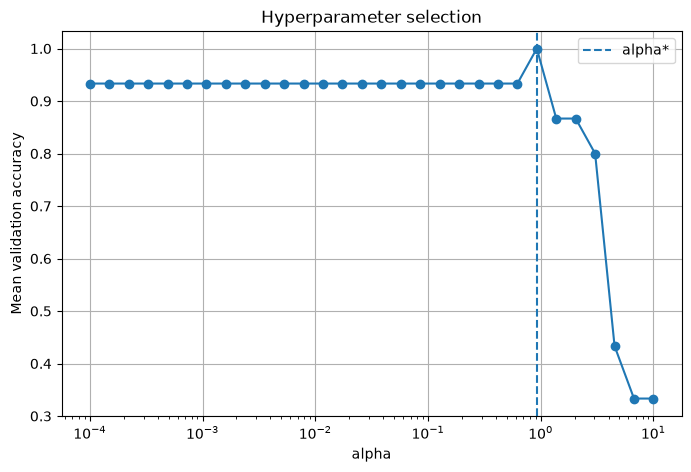

In [6]:
alphas = np.logspace(-4, 1, 30)
mean_scores = []

for alpha in alphas:
    scores = []
    for validation_fold in range(5):
        validation_idx = folds[validation_fold]
        training_idx = np.concatenate([folds[i] for i in range(5) if i != validation_fold])
        theta, theta0, _ = fit_linear_svm(X[training_idx], y[training_idx], alpha=alpha, epochs=1000)
        scores.append(accuracy(X[validation_idx], y[validation_idx], theta, theta0))
    mean_scores.append(np.mean(scores))

best = int(np.argmax(mean_scores))
alpha_star = float(alphas[best])
print('alpha* =', alpha_star)
print('best mean validation accuracy =', mean_scores[best])

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_scores, marker='o')
plt.axvline(alpha_star, linestyle='--', label='alpha*')
plt.xlabel('alpha')
plt.ylabel('Mean validation accuracy')
plt.title('Hyperparameter selection')
plt.grid(True)
plt.legend()
plt.show()

## The two optimization levels

Parameter optimization: $\theta^*(\alpha)=\arg\min_{\theta}J(\theta;\alpha)$.

Hyperparameter selection: $\alpha^*=\arg\max_{\alpha}S(\alpha)$.

This is why Lecture 4 reuses our Lecture 3 optimizer and adds cross-validation around it.